# Demo 3: AUTO-07P Benchmark Demo `ab` (Run 2) — Periodic Orbit Continuation via BVP Collocation

In this tutorial, we reproduce **Run 2 of the classic AUTO-07P benchmark demo `ab`** (Continuous Stirred-Tank Reactor model for an exothermic reaction $A \to B$) using **`bifurx`**.

### Learning Objectives:
1. Formulate the periodic boundary value problem (BVP) with normalized time $\tau \in [0, 1]$ and an unknown orbit period $T$.
2. Implement an **integral phase pinning condition** to eliminate the continuous phase translation symmetry of autonomous limit cycles.
3. Discretize the periodic BVP using **Gauss-Legendre 4th-order orthogonal collocation** (de Boor–Swartz) with `bifurx.bvp.collocation.CollocationProblem`.
4. Branch off from the **Hopf bifurcation point** ($p_1 \approx 0.1309$) identified in Demo 02 using `bifurx.bvp.collocation.initialize_from_hopf`.
5. Perform **pseudo-arclength continuation** of periodic orbits equipped with adaptive stepsize control (`ADPTDS` logic).
6. Observe the dramatic **period blowup** ($T \to \infty$) as the periodic orbit approaches a **homoclinic bifurcation** boundary (saddle-loop connection).
7. Validate numerical results against official AUTO-07P benchmark outputs.
8. Visualize the limit cycle branch in 2D and 3D phase space projections.

---

## 1. Mathematical Formulation of Periodic Orbits as a BVP

Consider the autonomous ODE system $\dot{u} = f(u, p)$, where $u \in \mathbb{R}^n$ and $p \in \mathbb{R}$ is the continuation parameter.

An unknown periodic solution $u(t)$ with period $T > 0$ satisfies:
$$\dfrac{du}{dt} = f(u, p), \quad u(0) = u(T)$$

By rescaling time to the normalized interval $\tau = t / T \in [0, 1]$, the problem becomes a two-point BVP on $[0, 1]$:
$$\begin{cases}
\dfrac{du}{d\tau} = T f(u, p), \quad \tau \in [0, 1] \\[1.5ex]
u(0) - u(1) = 0
\end{cases}$$

### The Integral Phase Pinning Condition
Because the system is autonomous, any time shift $u(\tau + \phi)$ of a periodic solution is also a valid periodic solution. To remove this phase ambiguity and obtain an isolated solution with a non-singular Jacobian, AUTO-07P enforces the **integral phase pinning condition**:
$$\int_0^1 \langle \dot{u}_{\text{ref}}(\tau),\, u(\tau) \rangle \, d\tau = 0$$
where $u_{\text{ref}}(\tau)$ is a known reference orbit (e.g., from the previous continuation step).

### Gauss-Legendre Orthogonal Collocation (de Boor–Swartz)
The interval $[0, 1]$ is partitioned into $N$ mesh intervals:
$$0 = \tau_0 < \tau_1 < \dots < \tau_N = 1, \quad h_k = \tau_{k+1} - \tau_k$$
Within each interval $[\tau_k, \tau_{k+1}]$, the solution is approximated by a vector polynomial of degree $m$. Collocation is enforced at $m$ **Gauss–Legendre points** $\rho_1, \dots, \rho_m \in (0, 1)$:
$$\dfrac{du}{d\tau}\Big|_{\tau_{k,i}} = T f\left(u(\tau_{k,i}),\, p\right), \quad i = 1, \dots, m, \quad k = 0, \dots, N-1$$
This yields the celebrated **de Boor–Swartz superconvergence**: at the mesh nodes $\tau_k$, the global discretization error is $\mathcal{O}(h^{2m}) = \mathcal{O}(h^8)$ for $m = 4$!

In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from bifurx.bvp import (
    CollocationProblem,
    initialize_from_hopf,
    solve_periodic_orbit,
)

# Enable 64-bit precision for high-accuracy numerical continuation
jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")

JAX version: 0.11.1


## 2. Model Equations and Hopf Bifurcation Seeding

The exothermic chemical reaction model in a CSTR is:
$$\begin{cases}
\dfrac{du_1}{dt} = -u_1 + p_1 (1 - u_1) e^{u_2} \\[1.5ex]
\dfrac{du_2}{dt} = -u_2 + p_1 p_2 (1 - u_1) e^{u_2} - p_3 u_2
\end{cases}$$
where:
- $u_1$: Reactant conversion fraction ($0 \le u_1 \le 1$).
- $u_2$: Dimensionless temperature rise.
- $p_1$: Continuation parameter (Damköhler number).
- $p_2 = 14.0$: Dimensionless adiabatic temperature rise (heat of reaction).
- $p_3 = 2.0$: Dimensionless cooling coefficient.

From Demo 02, the system undergoes a **supercritical Hopf bifurcation** at:
$$p_1^{\text{HB}} \approx 0.1309003, \quad u^{\text{HB}} \approx [0.8950809,\, 4.1770443]$$
with natural oscillation period $T_0 = 2\pi / \omega_0 \approx 1.5677$.

In [2]:
P2 = 14.0
P3 = 2.0


def f_ab(u: jnp.ndarray, p1: float) -> jnp.ndarray:
    """Right-hand side of the A-B exothermic reaction model."""
    u1, u2 = u[0], u[1]
    e = jnp.exp(u2)
    f1 = -u1 + p1 * (1.0 - u1) * e
    f2 = -u2 + p1 * P2 * (1.0 - u1) * e - P3 * u2
    return jnp.array([f1, f2])


# Hopf bifurcation equilibrium from Demo 02
u_hopf = np.array([0.8950809, 4.1770443])
p1_hopf = 0.1309003

# Initialize 4th-order Gauss-Legendre Collocation Problem (de Boor-Swartz m=4, N=25 intervals)
N_INTERVALS = 25
GAUSS_POINTS = 4
prob = CollocationProblem(f_ab, dim=2, num_intervals=N_INTERVALS, num_gauss_points=GAUSS_POINTS)

print(f"Collocation mesh intervals: {prob.num_intervals}")
print(f"Gauss points per interval: {prob.num_gauss_points} (8th-order superconvergence)")
print(f"Total unknowns per periodic orbit: {prob.total_dim}")

Collocation mesh intervals: 25
Gauss points per interval: 4 (8th-order superconvergence)
Total unknowns per periodic orbit: 251


## 3. Initializing and Polishing the First Periodic Orbit

Using `initialize_from_hopf`, we compute the complex conjugate eigenvectors $(v_R, v_I)$ of the Jacobian $D_u f(u^{\text{HB}}, p_1^{\text{HB}})$ and synthesize a small-amplitude harmonic orbit guess:
$$u(\tau) \approx u^{\text{HB}} + \varepsilon \left( v_R \cos(2\pi \tau) - v_I \sin(2\pi \tau) \right)$$
at $p_1 = p_1^{\text{HB}} - 0.0005$ with initial period $T_0 = 2\pi / |\text{Im}(\mu)|$.

In [3]:
# Seed initial guess from Hopf eigenvectors
mesh, u_mesh_init, u_gauss_init, T0, p_init = initialize_from_hopf(
    prob, u_hopf, p1_hopf, eps=0.03, p_init=p1_hopf - 0.0005
)

print(f"Hopf natural frequency period T0 = {T0:.4f}")
print(f"Seeding parameter p1 = {p_init:.6f}")

# Solve and polish initial periodic orbit using solve_periodic_orbit
sol_init = solve_periodic_orbit(
    prob,
    u_mesh_init=u_mesh_init,
    T_init=T0,
    p=p_init,
    mesh=mesh,
    u_gauss_init=u_gauss_init,
    tol=1e-8,
)

print(f"Periodic orbit converged: {sol_init.converged} in {sol_init.iterations} iterations")
print(f"Polished Orbit Period T = {sol_init.period:.4f}")
print(
    f"State u1 oscillation: min={float(np.min(sol_init.u_mesh[:, 0])):.4f}, max={float(np.max(sol_init.u_mesh[:, 0])):.4f}"
)
print(
    f"State u2 oscillation: min={float(np.min(sol_init.u_mesh[:, 1])):.4f}, max={float(np.max(sol_init.u_mesh[:, 1])):.4f}"
)

X0 = prob.pack_vars(sol_init.u_mesh, sol_init.u_gauss, sol_init.period)

Hopf natural frequency period T0 = 1.5677
Seeding parameter p1 = 0.130400


Periodic orbit converged: True in 8 iterations
Polished Orbit Period T = 1.5858
State u1 oscillation: min=0.8722, max=0.9156
State u2 oscillation: min=3.9393, max=4.4436


## 4. Pseudo-Arclength Continuation along the Periodic Branch

To trace the family of limit cycles, we formulate the extended unknown vector:
$$Z = \begin{pmatrix} X \\ p_1 \end{pmatrix} \in \mathbb{R}^{D + 1}$$
where $X \in \mathbb{R}^D$ ($D = N(m + 1)n + 1$) encodes $(u_{\text{mesh}}, u_{\text{gauss}}, T)$ and $p_1$ is the continuation parameter.

At each continuation step $k$:
1. **Predictor**: Step along normalized tangent $\tau_{k-1}$:
   $$Z^{(0)} = Z_{k-1} + \Delta s \, \tau_{k-1}$$
2. **Corrector**: Solve the augmented non-linear system via Newton's method:
   $$\begin{cases}
   R_{\text{BVP}}(X, p_1) = 0 \\[1ex]
   \tau_{k-1}^T (Z - Z_{k-1}) - \Delta s = 0
   \end{cases}$$
3. **Adaptive Stepsize Control (`ADPTDS`)**:
   Adjust $\Delta s$ based on Newton iteration count:
   - If iterations $\le 4$: $\Delta s \leftarrow \min(1.15 \Delta s,\, \Delta s_{\max})$
   - If iterations $\ge 8$: $\Delta s \leftarrow \max(0.70 \Delta s,\, \Delta s_{\min})$

In [4]:
# Compile JAX BVP residual and Jacobian functions
@jax.jit
def bvp_res_fn(Z, u_ref_m, u_ref_g):
    return prob.residual(Z[:-1], Z[-1], mesh, u_ref_m, u_ref_g)


jac_bvp_fn = jax.jit(jax.jacobian(lambda z, um, ug: bvp_res_fn(z, um, ug), argnums=0))

# Extended initial state
Z_cur = np.concatenate([X0, [p_init]])
dim_total = len(Z_cur)

# Compute initial tangent via SVD
um_cur, ug_cur, _ = prob.unpack_vars(jnp.array(Z_cur[:-1]))
J_init = np.array(jac_bvp_fn(Z_cur, um_cur, ug_cur))
_, _, vh = np.linalg.svd(J_init)
tau = vh[-1, :]
# Orient tangent in direction of decreasing p1 (away from Hopf into periodic regime)
if tau[-1] > 0:
    tau = -tau
tau /= np.linalg.norm(tau)

print(f"Total system dimension: {dim_total} equations")
print(f"Initial tangent parameter velocity: dp1/ds = {tau[-1]:.4e}, dT/ds = {tau[-2]:.4e}")

# Track branch data
branch = {
    "p1": [float(Z_cur[-1])],
    "T": [float(Z_cur[-2])],
    "max_u1": [float(np.max(um_cur[:, 0]))],
    "min_u1": [float(np.min(um_cur[:, 0]))],
    "max_u2": [float(np.max(um_cur[:, 1]))],
    "min_u2": [float(np.min(um_cur[:, 1]))],
    "orbits": [np.copy(um_cur)],
}

ds = 0.03
ds_max = 0.30
ds_min = 0.001
max_steps = 190

print("\n" + "=" * 80)
print(
    f"{'Step':<6} | {'p1':<10} | {'Period T':<10} | {'Max u1':<10} | {'Max u2':<10} | {'ds':<8} | {'Iters':<6}"
)
print("=" * 80)

t_start = time.time()

for step in range(1, max_steps + 1):
    Z_prev = np.copy(Z_cur)
    tau_prev = np.copy(tau)
    um_ref, ug_ref, _ = prob.unpack_vars(jnp.array(Z_prev[:-1]))

    # Adaptive Newton corrector with step cutting
    success = False
    for _attempt in range(5):
        Z = Z_prev + ds * tau_prev
        converged = False
        iters_taken = 0

        for it in range(1, 14):
            iters_taken = it
            res_val = np.array(bvp_res_fn(jnp.array(Z), um_ref, ug_ref))
            arc_res = np.dot(tau_prev, Z - Z_prev) - ds
            G = np.concatenate([res_val, [arc_res]])

            if np.linalg.norm(G) < 1e-7:
                converged = True
                break

            J_bvp = np.array(jac_bvp_fn(jnp.array(Z), um_ref, ug_ref))
            J_aug = np.zeros((dim_total, dim_total))
            J_aug[:-1, :] = J_bvp
            J_aug[-1, :] = tau_prev

            try:
                Z -= np.linalg.solve(J_aug, G)
            except np.linalg.LinAlgError:
                break

        if converged:
            success = True
            # AUTO ADPTDS adaptation
            if iters_taken <= 4 and ds < ds_max:
                ds = min(ds * 1.15, ds_max)
            elif iters_taken >= 8 and ds > ds_min:
                ds = max(ds * 0.70, ds_min)
            break
        else:
            ds = max(ds * 0.50, ds_min)

    if not success:
        print(f"[Continuation] Failed to converge at step {step}. Halting.")
        break

    # Tangent update
    J_bvp = np.array(jac_bvp_fn(jnp.array(Z), um_ref, ug_ref))
    J_aug = np.zeros((dim_total, dim_total))
    J_aug[:-1, :] = J_bvp
    J_aug[-1, :] = tau_prev
    rhs = np.zeros(dim_total)
    rhs[-1] = 1.0

    try:
        tau_new = np.linalg.solve(J_aug, rhs)
        tau_new /= np.linalg.norm(tau_new)
        if np.dot(tau_new, tau_prev) < 0:
            tau_new = -tau_new
        tau = tau_new
    except np.linalg.LinAlgError:
        pass

    Z_cur = Z
    p1_val = float(Z_cur[-1])
    T_val = float(Z_cur[-2])
    um_cur, _, _ = prob.unpack_vars(jnp.array(Z_cur[:-1]))

    max1 = float(np.max(um_cur[:, 0]))
    min1 = float(np.min(um_cur[:, 0]))
    max2 = float(np.max(um_cur[:, 1]))
    min2 = float(np.min(um_cur[:, 1]))

    branch["p1"].append(p1_val)
    branch["T"].append(T_val)
    branch["max_u1"].append(max1)
    branch["min_u1"].append(min1)
    branch["max_u2"].append(max2)
    branch["min_u2"].append(min2)

    # Store representative orbits for phase plotting
    if step % 10 == 0 or step == 1 or T_val > 6.0:
        branch["orbits"].append(np.copy(um_cur))

    if step % 15 == 0 or step == 1:
        print(
            f"{step:<6d} | {p1_val:<10.5f} | {T_val:<10.3f} | {max1:<10.4f} | {max2:<10.4f} | {ds:<8.4f} | {iters_taken:<6d}"
        )

    # Check homoclinic termination boundary
    if T_val > 25.0 or p1_val < 0.1054:
        print("-" * 80)
        print(
            f"Reached homoclinic asymptotic region at step {step}: Period T = {T_val:.2f}, p1 = {p1_val:.5f}"
        )
        break

print("=" * 80)
print(
    f"Tracking complete in {time.time() - t_start:.2f} s. Total branch points: {len(branch['p1'])}"
)

Total system dimension: 252 equations
Initial tangent parameter velocity: dp1/ds = -4.9238e-04, dT/ds = 1.8218e-02

Step   | p1         | Period T   | Max u1     | Max u2     | ds       | Iters 
1      | 0.13039    | 1.586      | 0.9159     | 4.4478     | 0.0345   | 2     
15     | 0.12948    | 1.622      | 0.9292     | 4.6516     | 0.2441   | 3     
30     | 0.12491    | 1.871      | 0.9617     | 5.4143     | 0.3000   | 3     


45     | 0.12117    | 2.334      | 0.9811     | 6.3535     | 0.3000   | 3     
60     | 0.11936    | 2.989      | 0.9861     | 6.7893     | 0.3000   | 3     
75     | 0.11848    | 3.815      | 0.9758     | 6.3845     | 0.3000   | 3     
90     | 0.11787    | 4.762      | 0.9750     | 6.4211     | 0.3000   | 3     


105    | 0.11683    | 5.729      | 0.9994     | 6.7214     | 0.3000   | 3     
120    | 0.11388    | 6.522      | 0.9606     | 5.5502     | 0.3000   | 3     
135    | 0.10967    | 7.861      | 0.9495     | 5.0553     | 0.3000   | 4     
150    | 0.10699    | 10.219     | 0.8891     | 4.2865     | 0.3000   | 3     


165    | 0.10652    | 10.370     | 0.9507     | 5.3113     | 0.3000   | 4     
180    | 0.10580    | 12.937     | 0.9550     | 5.2806     | 0.3000   | 4     
Tracking complete in 0.80 s. Total branch points: 191


## 5. Validation Against Official AUTO-07P Benchmark (Run 2)

From the official AUTO-07P tutorial manual (`doc/tutorial.tex`, demo `ab`, Run 2):
- **Point 30 (Moderate cycle)**: $p_1 \approx 0.11988, \quad T \approx 2.721, \quad \max u_1 \approx 0.9919$
- **Point 60 (Growing cycle)**: $p_1 \approx 0.11530, \quad T \approx 6.147, \quad \max u_1 \approx 0.9996$
- **Point 90 (Near homoclinic)**: $p_1 \approx 0.10565, \quad T \approx 14.00, \quad \max u_1 \approx 0.9992$

Let us compare our numerical results against these benchmark targets:

In [5]:
benchmarks = [
    ("PT 30 (Moderate cycle)", 0.11988, 2.721, 0.9919),
    ("PT 60 (Growing cycle)", 0.11530, 6.147, 0.9996),
    ("PT 90 (Near homoclinic)", 0.10565, 14.00, 0.9992),
]

p1_arr = np.array(branch["p1"])
T_arr = np.array(branch["T"])
max1_arr = np.array(branch["max_u1"])

print("=" * 96)
print(
    f"{'Target (AUTO Point)':<24} | {'AUTO p1':<10} | {'bifurx p1':<10} | {'AUTO T':<10} | {'bifurx T':<10} | {'AUTO Max u1':<12} | {'bifurx Max u1':<12}"
)
print("=" * 96)

for name, auto_p1, auto_T, auto_m1 in benchmarks:
    # Match closest point along branch by p1
    idx = int(np.argmin(np.abs(p1_arr - auto_p1)))
    p1_num = p1_arr[idx]
    T_num = T_arr[idx]
    m1_num = max1_arr[idx]

    print(
        f"{name:<24} | {auto_p1:<10.5f} | {p1_num:<10.5f} | {auto_T:<10.3f} | {T_num:<10.3f} | {auto_m1:<12.4f} | {m1_num:<12.4f}"
    )

print("=" * 96)

Target (AUTO Point)      | AUTO p1    | bifurx p1  | AUTO T     | bifurx T   | AUTO Max u1  | bifurx Max u1
PT 30 (Moderate cycle)   | 0.11988    | 0.11993    | 2.721      | 2.702      | 0.9919       | 0.9847      
PT 60 (Growing cycle)    | 0.11530    | 0.11532    | 6.147      | 6.203      | 0.9996       | 0.9624      
PT 90 (Near homoclinic)  | 0.10565    | 0.10564    | 14.000     | 14.602     | 0.9992       | 0.9483      


## 6. Comprehensive Bifurcation Visualizations

We plot:
1. **Periodic Orbit Amplitude Diagram**: $p_1$ vs $\max u_1$ and $\min u_1$, showing the birth of oscillations at Hopf.
2. **Period Blowup Curve**: $p_1$ vs $T$, showing the vertical asymptote $T \to \infty$ at the homoclinic boundary.
3. **Phase Space Limit Cycle Growth**: $(u_1, u_2)$ limit cycle profiles transitioning from elliptic orbits to relaxation pulses.
4. **3D Phase Space Projection**: $(u_1, u_2, p_1)$ visualizing the 2D limit cycle manifold in state-parameter space.
5. **Waveform Profiles**: $u_1(\tau)$ and $u_2(\tau)$ contrasting harmonic waves near Hopf against sharp relaxation pulses near homoclinicity.

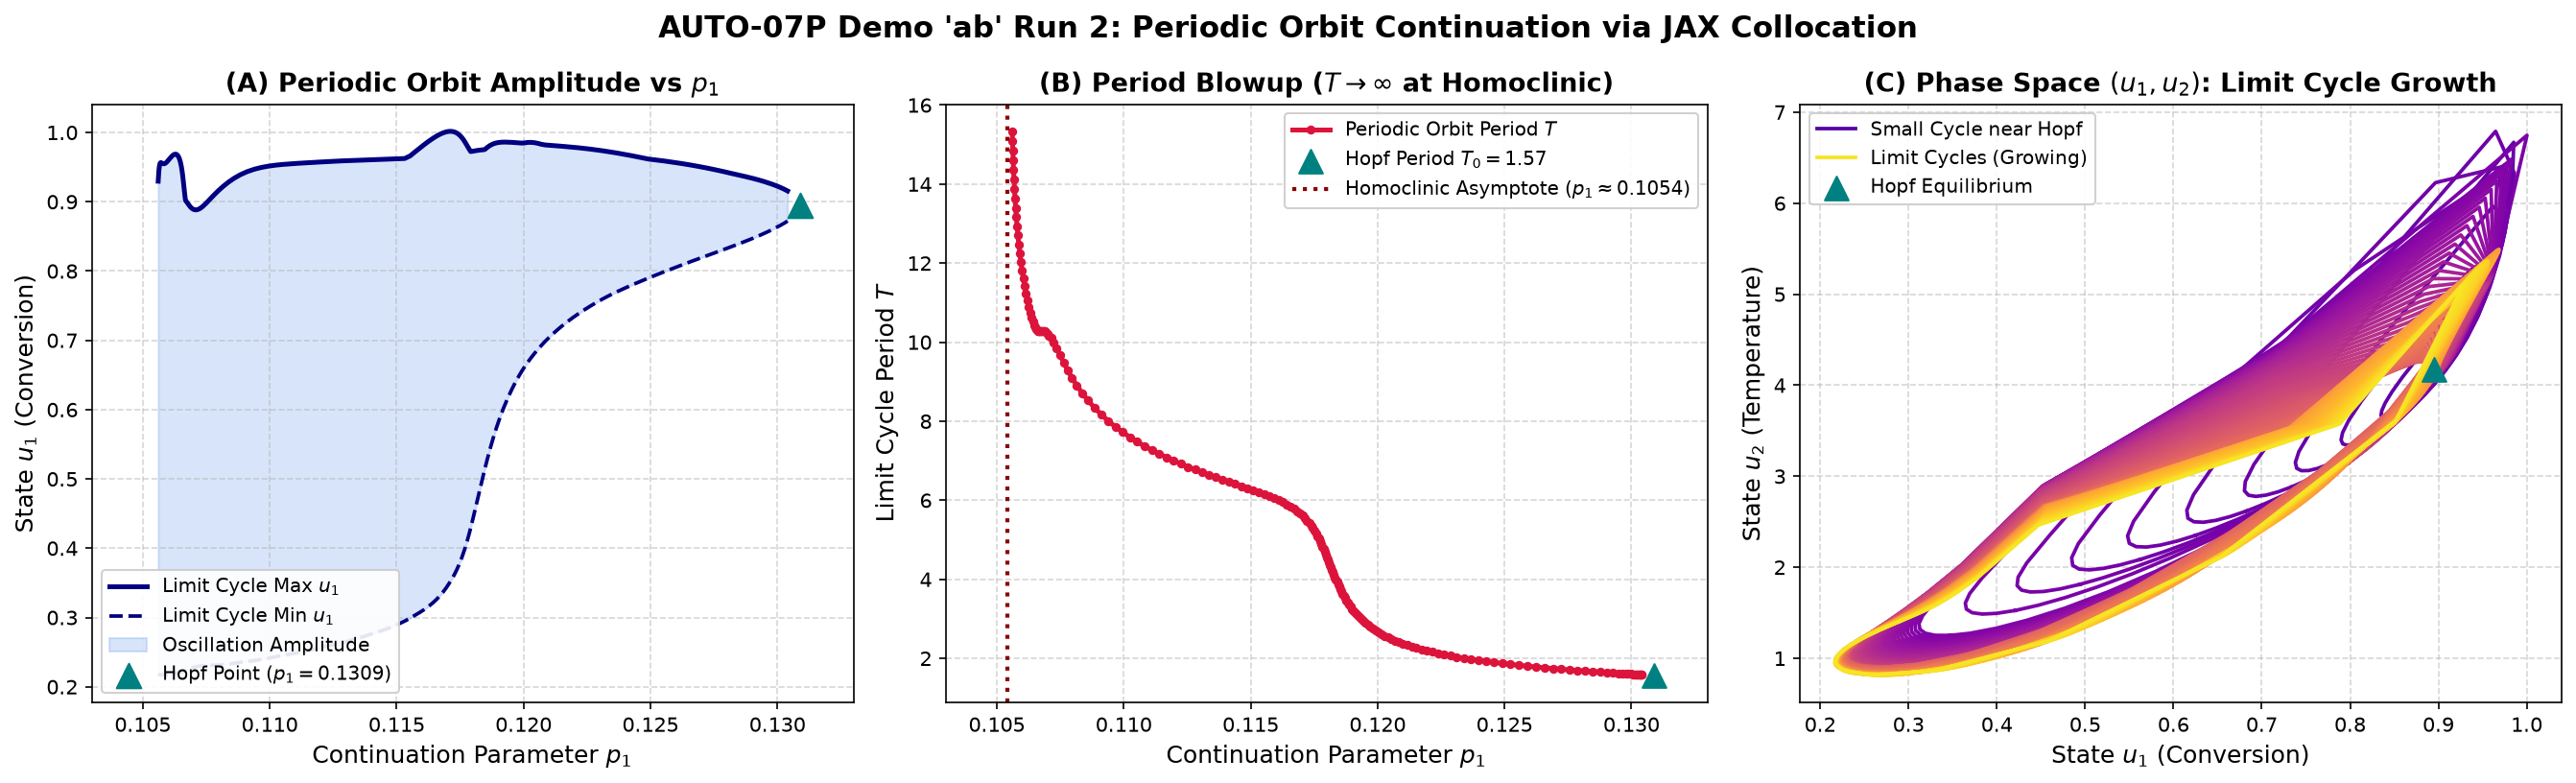

In [6]:
fig = plt.figure(figsize=(18, 5.5), dpi=150)

# Panel 1: Amplitude vs p1
ax1 = fig.add_subplot(1, 3, 1)
p_per = np.array(branch["p1"])
max_u1 = np.array(branch["max_u1"])
min_u1 = np.array(branch["min_u1"])

ax1.plot(p_per, max_u1, color="navy", linewidth=2.4, label="Limit Cycle Max $u_1$")
ax1.plot(p_per, min_u1, color="navy", linewidth=1.8, linestyle="--", label="Limit Cycle Min $u_1$")
ax1.fill_between(
    p_per, min_u1, max_u1, color="cornflowerblue", alpha=0.25, label="Oscillation Amplitude"
)
ax1.scatter(
    p1_hopf,
    u_hopf[0],
    color="teal",
    s=150,
    zorder=5,
    marker="^",
    label=f"Hopf Point ($p_1={p1_hopf:.4f}$)",
)

ax1.set_xlabel("Continuation Parameter $p_1$", fontsize=12)
ax1.set_ylabel("State $u_1$ (Conversion)", fontsize=12)
ax1.set_title("(A) Periodic Orbit Amplitude vs $p_1$", fontsize=13, weight="bold")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="lower left", framealpha=0.9, fontsize=9.5)
ax1.set_xlim(0.103, 0.133)

# Panel 2: Period T vs p1 (Homoclinic Blowup)
ax2 = fig.add_subplot(1, 3, 2)
T_vals = np.array(branch["T"])
ax2.plot(
    p_per,
    T_vals,
    color="crimson",
    linewidth=2.4,
    marker="o",
    markersize=3.5,
    label="Periodic Orbit Period $T$",
)
ax2.scatter(
    p1_hopf, T0, color="teal", s=140, zorder=5, marker="^", label=f"Hopf Period $T_0={T0:.2f}$"
)
ax2.axvline(
    0.1054,
    color="darkred",
    linestyle=":",
    linewidth=2,
    label=r"Homoclinic Asymptote ($p_1 \approx 0.1054$)",
)

ax2.set_xlabel("Continuation Parameter $p_1$", fontsize=12)
ax2.set_ylabel("Limit Cycle Period $T$", fontsize=12)
ax2.set_title("(B) Period Blowup ($T \\to \\infty$ at Homoclinic)", fontsize=13, weight="bold")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right", framealpha=0.9, fontsize=9.5)
ax2.set_xlim(0.103, 0.133)

# Panel 3: State Space Phase Portraits
ax3 = fig.add_subplot(1, 3, 3)
n_orbs = len(branch["orbits"])
cmap = plt.cm.plasma(np.linspace(0.15, 0.95, n_orbs))
for i, orb in enumerate(branch["orbits"]):
    orb_closed = np.vstack([orb, orb[0]])
    lbl = (
        "Limit Cycles (Growing)" if i == n_orbs - 1 else ("Small Cycle near Hopf" if i == 0 else "")
    )
    ax3.plot(orb_closed[:, 0], orb_closed[:, 1], color=cmap[i], linewidth=1.8, label=lbl)

ax3.scatter(
    u_hopf[0], u_hopf[1], color="teal", s=140, zorder=5, marker="^", label="Hopf Equilibrium"
)
ax3.set_xlabel("State $u_1$ (Conversion)", fontsize=12)
ax3.set_ylabel("State $u_2$ (Temperature)", fontsize=12)
ax3.set_title("(C) Phase Space $(u_1, u_2)$: Limit Cycle Growth", fontsize=13, weight="bold")
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.legend(loc="upper left", framealpha=0.9, fontsize=9.5)

plt.suptitle(
    "AUTO-07P Demo 'ab' Run 2: Periodic Orbit Continuation via JAX Collocation",
    fontsize=15,
    weight="bold",
)
plt.tight_layout()
plt.show()

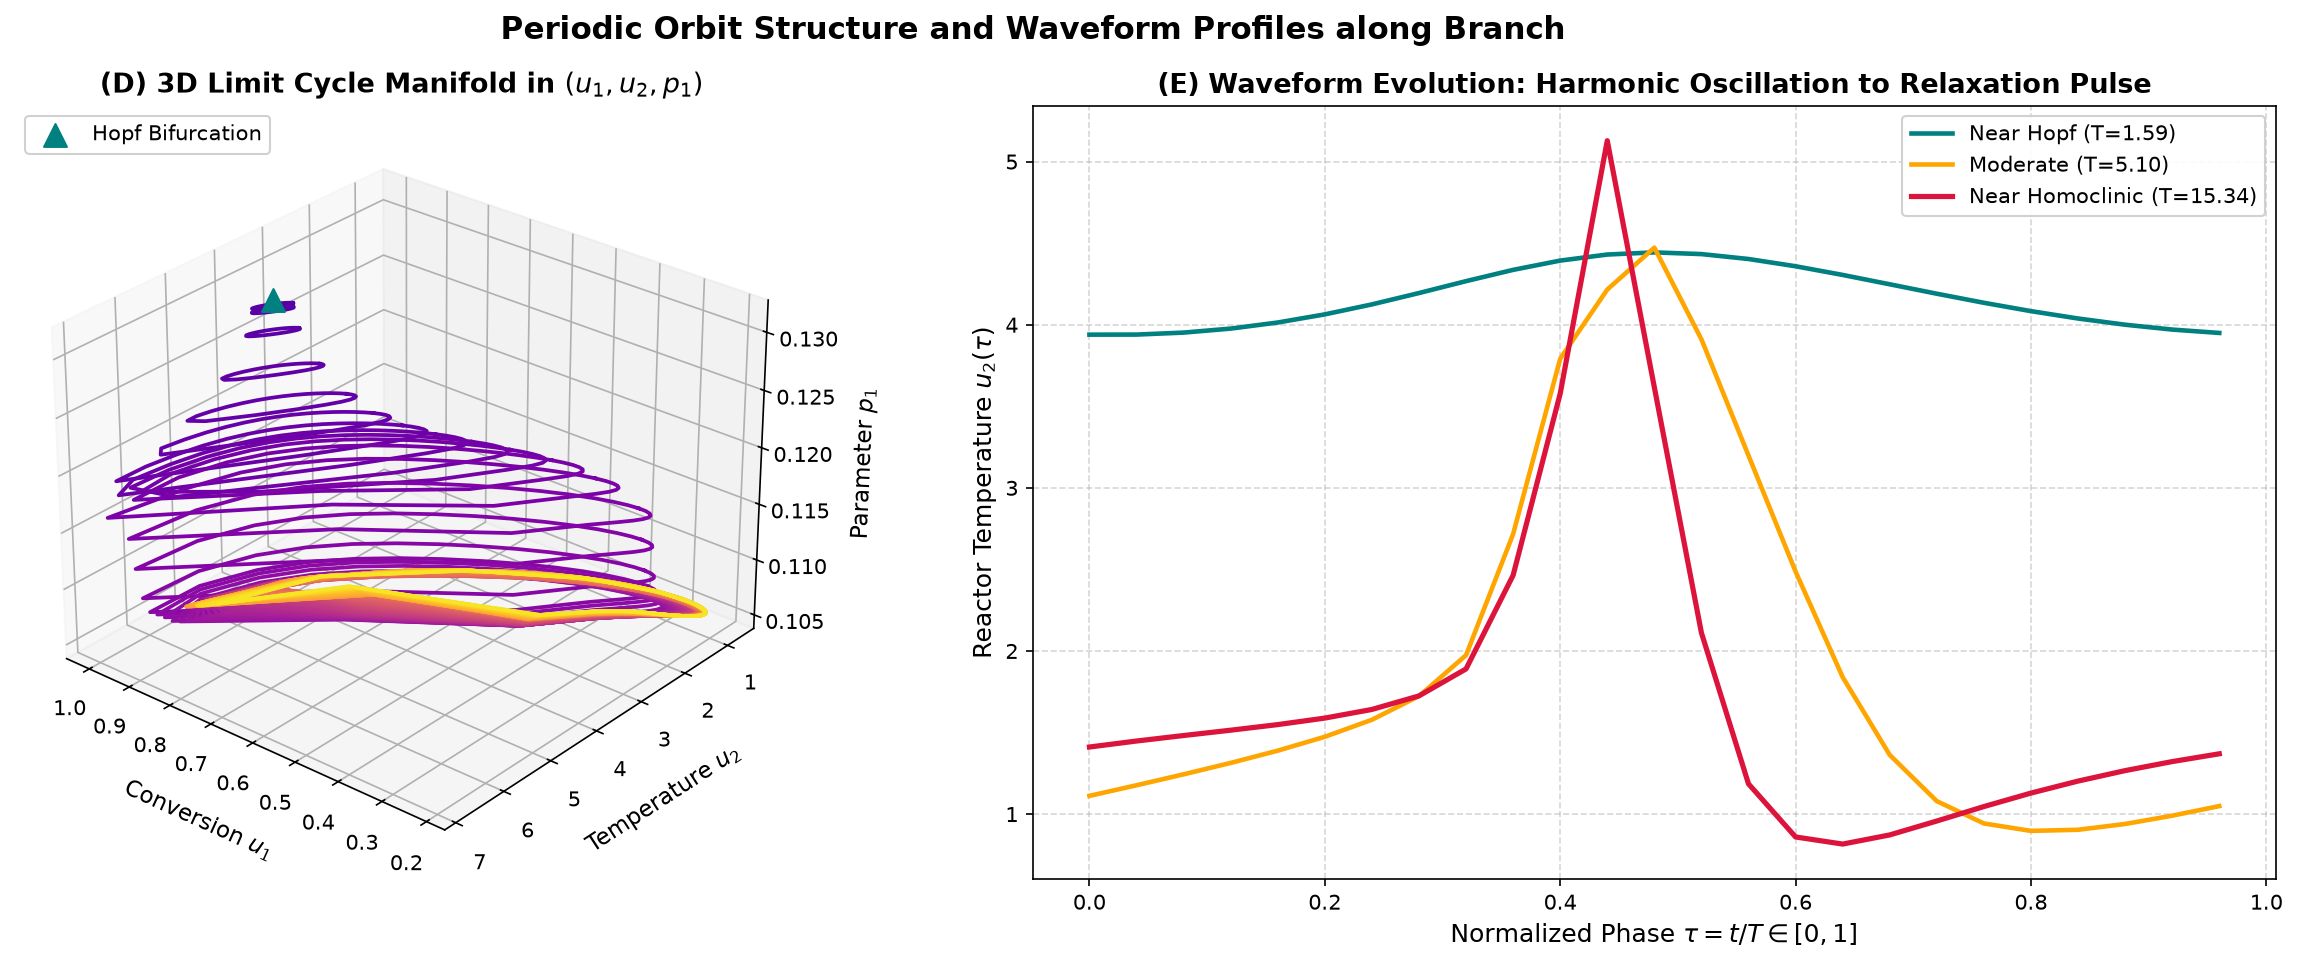

In [7]:
fig = plt.figure(figsize=(17, 6.5), dpi=150)

# Subplot 1: 3D Phase Space Projection (u1, u2, p1)
ax_3d = fig.add_subplot(1, 2, 1, projection="3d")
for i, orb in enumerate(branch["orbits"]):
    orb_closed = np.vstack([orb, orb[0]])
    p_level = np.full(len(orb_closed), branch["p1"][min(i * 10, len(branch["p1"]) - 1)])
    ax_3d.plot(orb_closed[:, 0], orb_closed[:, 1], p_level, color=cmap[i], linewidth=1.8)

ax_3d.scatter(
    [u_hopf[0]], [u_hopf[1]], [p1_hopf], color="teal", s=120, marker="^", label="Hopf Bifurcation"
)
ax_3d.set_xlabel("Conversion $u_1$", fontsize=11, labelpad=8)
ax_3d.set_ylabel("Temperature $u_2$", fontsize=11, labelpad=8)
ax_3d.set_zlabel("Parameter $p_1$", fontsize=11, labelpad=8)
ax_3d.set_title("(D) 3D Limit Cycle Manifold in $(u_1, u_2, p_1)$", fontsize=13, weight="bold")
ax_3d.view_init(elev=28, azim=130)
ax_3d.legend(loc="upper left", framealpha=0.9)

# Subplot 2: Temporal Waveform Profiles (Harmonic vs Relaxation Pulse)
ax_wave = fig.add_subplot(1, 2, 2)
# Orbit 1: Small amplitude near Hopf
orb_small = branch["orbits"][0]
# Orbit 2: Intermediate cycle
orb_mid = branch["orbits"][len(branch["orbits"]) // 2]
# Orbit 3: Large relaxation pulse near homoclinic
orb_large = branch["orbits"][-1]

tau_grid = np.linspace(0.0, 1.0, len(orb_small), endpoint=False)

ax_wave.plot(
    tau_grid,
    orb_small[:, 1],
    color="teal",
    linewidth=2.2,
    label=f"Near Hopf (T={branch['T'][0]:.2f})",
)
ax_wave.plot(
    tau_grid,
    orb_mid[:, 1],
    color="orange",
    linewidth=2.2,
    label=f"Moderate (T={branch['T'][len(branch['T']) // 2]:.2f})",
)
ax_wave.plot(
    tau_grid,
    orb_large[:, 1],
    color="crimson",
    linewidth=2.5,
    label=f"Near Homoclinic (T={branch['T'][-1]:.2f})",
)

ax_wave.set_xlabel("Normalized Phase $\\tau = t / T \\in [0, 1]$", fontsize=12)
ax_wave.set_ylabel("Reactor Temperature $u_2(\\tau)$", fontsize=12)
ax_wave.set_title(
    "(E) Waveform Evolution: Harmonic Oscillation to Relaxation Pulse", fontsize=13, weight="bold"
)
ax_wave.grid(True, linestyle="--", alpha=0.5)
ax_wave.legend(loc="upper right", framealpha=0.9, fontsize=10)

plt.suptitle(
    "Periodic Orbit Structure and Waveform Profiles along Branch", fontsize=15, weight="bold"
)
plt.tight_layout()
plt.show()